<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/MSOC_banner.png' align='right' width='100%'/>

<a href="../Index.ipynb">Index</a> | <a href="./Access_OLCI_EUMETSAT_Data_Store.ipynb">Accessing Sentinel-3 OLCI data through the EUMETSAT Data Store</a> | <a href="./Access_PACE_EarthData.ipynb">Accessing PACE OCI through EarthData</a> | <a href="./Access_MSI_CDSE.ipynb">Accessing Sentinel-2 MSI data via the CDSE</a> 

**Copyright:** 2026 European Union <br>
**License:** MIT <br>
**Authors:** Ben Loveday (Innoflair for EUMETSAT), Hayley Evers-King (EUMETSAT), Vittorio Brando (CNR)

<div class="alert alert-block alert-success">
<h3>Multi-sensor Ocean Colour Course</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
This notebook has the following prerequisites:
- **<a href="https://data.marine.copernicus.eu/register" target="_blank">A Copernicus Marine Service account</a>** if you are using or plan to use the CMEMS Data Store

There are no prerequisite notebooks for this module.
</div>
<hr>

# Accessing multisensor ocean colour products data via the Copernicus Marine Service Data Store

### Data used

| Dataset | Copernicus Marine<br>Data Store product ID | Copernicus Marine<br>product description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L3 (daily) from Satellite Observations (Near Real Time) | OCEANCOLOUR_GLO_BGC_L3_NRT_009_101 | <a href="https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L3_NRT_009_101/description" target="_blank">Description</a> | OCEANCOLOUR_GLO_BGC_L3_NRT_009_101 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AMO%3ADAT%3AOCEANCOLOUR_GLO_BGC_L3_NRT_009_101" target="_blank">Description</a> |
| North Atlantic Ocean Colour Plankton, Reflectance, Transparency and Optics L3 NRT daily observations |  OCEANCOLOUR_ATL_BGC_L3_NRT_009_111 | <a href="https://data.marine.copernicus.eu/product/OCEANCOLOUR_ATL_BGC_L3_NRT_009_111/description" target="_blank">Description</a> | OCEANCOLOUR_ATL_BGC_L3_NRT_009_111 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AMO%3ADAT%3AOCEANCOLOUR_ATL_BGC_L3_NRT_009_111" target="_blank">Description</a> |
| Baltic Sea Ocean Colour Plankton, Reflectances, Transparency and Optics L3 NRT daily observations | OCEANCOLOUR_BAL_BGC_L3_NRT_009_131 | <a href="https://data.marine.copernicus.eu/product/OCEANCOLOUR_BAL_BGC_L3_NRT_009_131/description" target="_blank">Description</a> | OCEANCOLOUR_BAL_BGC_L3_NRT_009_131 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AMO%3ADAT%3AOCEANCOLOUR_BAL_BGC_L3_NRT_009_131" target="_blank">Description</a> |

### Learning outcomes

At the end of this notebook you will know;
* how to search and download data from the CMEMS Data Store using the <font color="#138D75">**Copernicus Marine toolbox**</font> client
* How to refine your <font color="#138D75">**searches**</font> for multi-sensor ocean colour products
* How to refine your searches for temporal, spatial and variable coverage parameters
* How to <font color="#138D75">**download**</font> filtered products

### Outline

The Copernicus Marine Service (CMEMS) Data Store contains many ocean colour products, with regional and global coverage. These are available as near real-time or multi-year, reprocessed products. The CMEMS Data Store can be accessed via GUI and offers a series of APIs to facilitate programmatic interfaces. In this notebook, we will show you how to use these APIs to search for, filter and download multi-sensor ocean colour data, by exploiting the `copernicusmarine` <a href="https://help.marine.copernicus.eu/en/collections/9080063-copernicus-marine-toolbox" target="_target">toolbox</a>.

<hr>

<div class="alert alert-info" role="alert">

## Importing dependencies

</div>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [1]:
import copernicusmarine       # a library to help us access CMEMS data
import eumartools             # a EUMETSAT library that support working with Copernicus Sentinel products
import os                     # a library that allows us access to basic operating system commands like making directories
from pathlib import Path      # a library that helps construct system path objects
import datetime               # a library that allows us to work with dates and times
import xarray as xr           # a library that supports the use of multi-dimensional arrays in Python
import numpy as np            # a library that provides support for array-based mathematics

Next we will create a download directory to store the products we will download in this notebook.

In [2]:
download_dir = os.path.join(os.path.dirname(os.getcwd()), "Data", "Preprepared", "Day1", "Data_access", "CMEMS")
os.makedirs(download_dir, exist_ok=True)

<div class="alert alert-info" role="alert">

## Exploring level-3 ocean colour products from the Copernicus Marine Service

</div>

To generate a long time series of ocean colour measurements requires combining data from multiple satellite missions, and applying algorithms that are suitable for this, taking in to account the different spectral configurations etc of the missions. For example, above we apply the MPH which only uses wavebands available on Sentinel-3 OLCI, and the historical MERIS mission. This limits it's suitability for application to long time series. Further it is designed for focusing on blooms, and doesn't account for other forms of variability which are present in the Baltic sea.

As an optimal approach, we will access data from the Copernicus marine service where a regionally trained neural network using multiple algorithmic approaches is applied to multiyear records of ocean colour [[3]](#ref3). We will access data from the Copernicus Marine Service using the Copernicus Marine API. This loads data directly into memory, without the need to write anythin to a file.

<div class="alert alert-block alert-success">

### Accessing Copernicus Marine Service products

To retrieve the data, we need will use the <a href="https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction" target="_blank">Copernicus Marine API</a>. This allows us to remotely subset the data and either download it or read it directly into memory, for immediate use. If you are working with the recommended Anaconda Python distribution and used the environment file included in this repository (environment.yml) to build this python environment (as detailed in the README), you will already have installed this. If not, you can install the toolkit using;

`conda install -c conda-forge copernicusmarine`

To download data using the Copernicus Marine API, you need to provide credentials. To obtain these, you should register at the <a href="https://data.marine.copernicus.eu/register" target="_blank">Copernicus Marine Service</a> for an account and take note of you `username` and `password`. If you do not already have a local credentials file, you will be prompted to enter your credentials when you run the cell below. This will create the required local credentials file, so that you only need to run this once.

*Note: For more information on authentication options please see this <a href="https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration" target="_blank">web article</a>.*

</div>

Lets start by creating a credentials file to support authorisation of the service.

In [3]:
# Default location expected by the copernicusmarine package
copernicus_marine_credentials_file = Path(Path.home() / '.copernicusmarine' / '.copernicusmarine-credentials')

# Create it only if it does not already exists
if not copernicus_marine_credentials_file.is_file():
    copernicusmarine.login()

Now we have authorised the toolbox, we can make requests from the CMEMS Data Store. Lets start forming our search by setting the required product. Each product (as referenced in the "Data Used" table above) contains a series of data sets. Usually, we want to select only one. Fortunately, the naming of the data set matches a consistent pattern, as follows:

`cmems_obs-oc_{region}_bgc-{product}_{rec}_l3-{sensors}-{resolution}_P{timing}`

Lets set these parameters...

In [4]:
# Region or coverage area: glo, bal, atl etc...
region = "glo"

# Product: plankton, reflectance etc...
product = "plankton"

# Sensors: olci, multi
sensors = "olci"

# Resolution: 300m (olci), 4km (olci, multi)
resolution = "300m"

# Timing: 1D, 1M
timing = "1D"

# record type: my, nrt
rec = "my"

CMEMS_product = f"cmems_obs-oc_{region}_bgc-{product}_{rec}_l3-{sensors}-{resolution}_P{timing}"
print(CMEMS_product)

cmems_obs-oc_glo_bgc-plankton_my_l3-olci-300m_P1D


Lets now select the variable(s) we want from our product.

In [5]:
CMEMS_variables = ['CHL']

We want to refine our search by time and space. We can do this by setting an extraction box and start and end times, as follows;

In [6]:
# space filter for matching products
west = -83.50
south = 54.0
east = -82.0
north = 55.0

# time filter for matching products
dtstart = datetime.datetime(2025, 10, 24, 0, 0)
dtend = datetime.datetime(2025, 10, 25, 0, 0)

Finally, lets set the name of an output file for our download.

In [7]:
# collections
output_filename=os.path.join(os.getcwd(), download_dir, f"{CMEMS_product}_{dtstart.strftime('%Y%m%d')}_{dtend.strftime('%Y%m%d')}.nc")

Now we are authenticated, let's download our data set using the `subset` method in the `copernicusmarine` toolkit to retrieve our data. *Note that we are padding our search box and extraction dates to get a slightly larger/longer data load using the `box_pad` and `day_pad` variables. Also, it is possible to work with the CMEMS Data Store by streaming in data directly to a variable in memory, using the `open_dataset` method, which is very powerful)*

In [8]:
box_pad = 2
day_pad = 10

copernicusmarine.subset(
               dataset_id=CMEMS_product,
               variables=CMEMS_variables,
               minimum_longitude=west - box_pad,
               maximum_longitude=east + box_pad,
               minimum_latitude=south - box_pad,
               maximum_latitude=north + box_pad,
               start_datetime=(dtstart - datetime.timedelta(days=day_pad)).strftime("%Y-%m-%dT00:00:00.000Z"),
               end_datetime=(dtend + datetime.timedelta(days=day_pad)).strftime("%Y-%m-%dT00:00:00.000Z"),
               output_filename=output_filename);

INFO - 2026-07-10T11:05:42Z - Selected dataset version: "202211"
INFO - 2026-07-10T11:05:42Z - Selected dataset part: "default"


  0%|          | 0/65 [00:00<?, ?it/s]

Lets look at our DataSet...

In [9]:
ds_L3 = xr.open_dataset(output_filename)
ds_L3

<xarray.Dataset> Size: 78MB
Dimensions:    (time: 22, latitude: 900, longitude: 990)
Coordinates:
  * time       (time) datetime64[ns] 176B 2025-10-14 2025-10-15 ... 2025-11-04
  * latitude   (latitude) float32 4kB 52.0 52.01 52.01 ... 56.99 56.99 57.0
  * longitude  (longitude) float32 4kB -85.5 -85.49 -85.49 ... -80.01 -80.0
Data variables:
    CHL        (time, latitude, longitude) float32 78MB ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-28T21:04:20Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-olci...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0
    copernicusmarine_version:        2.3.0

We should see that we have a 3D data cube or our target variable(a) in latitude, longitude and time. Reading this product in as an `xarray` makes it extremely easy to use. For now, though, lets just check the mean coverage across our scene.

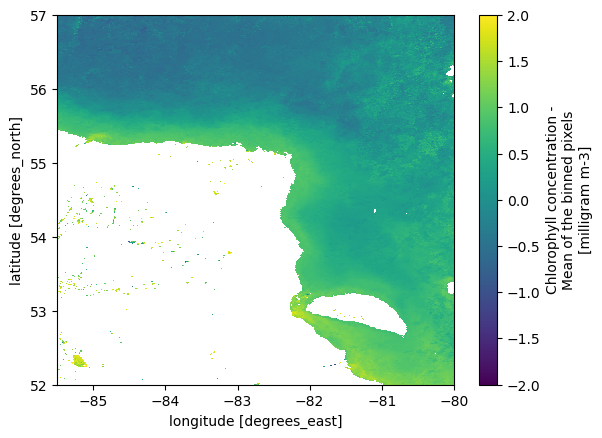

In [10]:
np.log10(ds_L3["CHL"]).mean(dim="time").plot.pcolormesh(cmap='viridis');

<div class="alert alert-success" role="alert">

## What next?

You should be able to adapt the methods above to search the Copernicus Marine Service (CMEMS) Data Store for the multi-sensor ocean colour data you require for this course, using your project ROI and time bounds information as input. If you need more information on using `copernicusmarine` toolbox to interface with the CMEMS Data Store you can find a comprehensive overview in the `copernicusmarine` toolbox <a href="https://help.marine.copernicus.eu/en/collections/9080063-copernicus-marine-toolbox" target="_target">online manual</a>.

</div>

<hr>
<a href="../Index.ipynb">Index</a> | <a href="./Access_OLCI_EUMETSAT_Data_Store.ipynb">Accessing Sentinel-3 OLCI data through the EUMETSAT Data Store</a> | <a href="./Access_PACE_EarthData.ipynb">Accessing PACE OCI through EarthData</a> | <a href="./Access_MSI_CDSE.ipynb">Accessing Sentinel-2 MSI data via the CDSE</a> 
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean">View on GitLab</a> | <a href="https://training.eumetsat.int/">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int>Contact helpdesk for support </a> | <a href=mailto:.training@eumetsat.int>Contact our training team to collaborate on and reuse this material</a></span></p>